<a href="https://colab.research.google.com/github/avionerman/neural-networks-msc/blob/main/plant_disease_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ταξινομηση Ασθενειων Φυτων με Convolutional Neural Network

Σε αυτο το notebook φτιαχνουμε ενα **CNN** που ταξινομει εικονες φυλλων φυτων σε **38 κατηγοριες** (υγιη φυτα και διαφορες ασθενειες).

**Dataset:** PlantVillage (~54.000 εικονες) - φορτωνεται αυτοματα μεσω TensorFlow Datasets, δεν χρειαζεται download απο Kaggle.

**Βηματα:**
1. Ελεγχος GPU
2. Φορτωση δεδομενων
3. Εξερευνηση δειγματων
4. Προεπεξεργασια
5. Κατασκευη του CNN (baseline)
6. Εκπαιδευση baseline
7. Καμπυλες εκπαιδευσης
8. Αξιολογηση στο test set
9. Confusion matrix
10. Παραδειγματα προβλεψεων
11. Hyperparameter Tuning με Keras Tuner
12. Εκπαιδευση τελικου μοντελου
13. Συγκριση Baseline vs Tuned

## 1. Ελεγχος GPU

Βεβαιωνομαστε οτι το Colab χρησιμοποιει GPU. Αν δεν εμφανιζει GPU, παμε:

**Runtime → Change runtime type → Hardware accelerator → GPU (T4)**

In [1]:
import tensorflow as tf

# Check if GPU is available
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU available: {len(gpus) > 0}")
print(f"Devices: {gpus}")

GPU available: True
Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Βιβλιοθηκες

Φορτωνουμε ολα τα απαραιτητα packages. Ολα ειναι ηδη εγκατεστημενα στο Colab.

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 3. Φορτωση δεδομενων

Κατεβαζουμε το PlantVillage dataset. Την πρωτη φορα θα παρει 1-2 λεπτα.

Χωριζουμε τα δεδομενα σε:
- **Train set:** 70% (για εκπαιδευση)
- **Validation set:** 15% (για ελεγχο κατα την εκπαιδευση)
- **Test set:** 15% (για τελικη αξιολογηση σε δεδομενα που δεν εχει δει το μοντελο)

In [3]:
# Load PlantVillage dataset and split into train/val/test
(ds_train, ds_val, ds_test), info = tfds.load(
    'plant_village',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    as_supervised=True,
    with_info=True
)

NUM_CLASSES = info.features['label'].num_classes
CLASS_NAMES = info.features['label'].names

print(f"Number of classes: {NUM_CLASSES}")
print(f"Total images: {info.splits['train'].num_examples}")
print(f"\nFirst 10 class names:")
for i, name in enumerate(CLASS_NAMES[:10]):
    print(f"  {i}: {name}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.19JRAE_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.
Number of classes: 38
Total images: 54303

First 10 class names:
  0: Apple___Apple_scab
  1: Apple___Black_rot
  2: Apple___Cedar_apple_rust
  3: Apple___healthy
  4: Blueberry___healthy
  5: Cherry___healthy
  6: Cherry___Powdery_mildew
  7: Corn___Cercospora_leaf_spot Gray_leaf_spot
  8: Corn___Common_rust
  9: Corn___healthy


## 4. Εξερευνηση δειγματων

Δειχνουμε 9 τυχαιες εικονες απο το training set μαζι με την κατηγορια τους, για να δουμε πως ειναι τα δεδομενα μας.

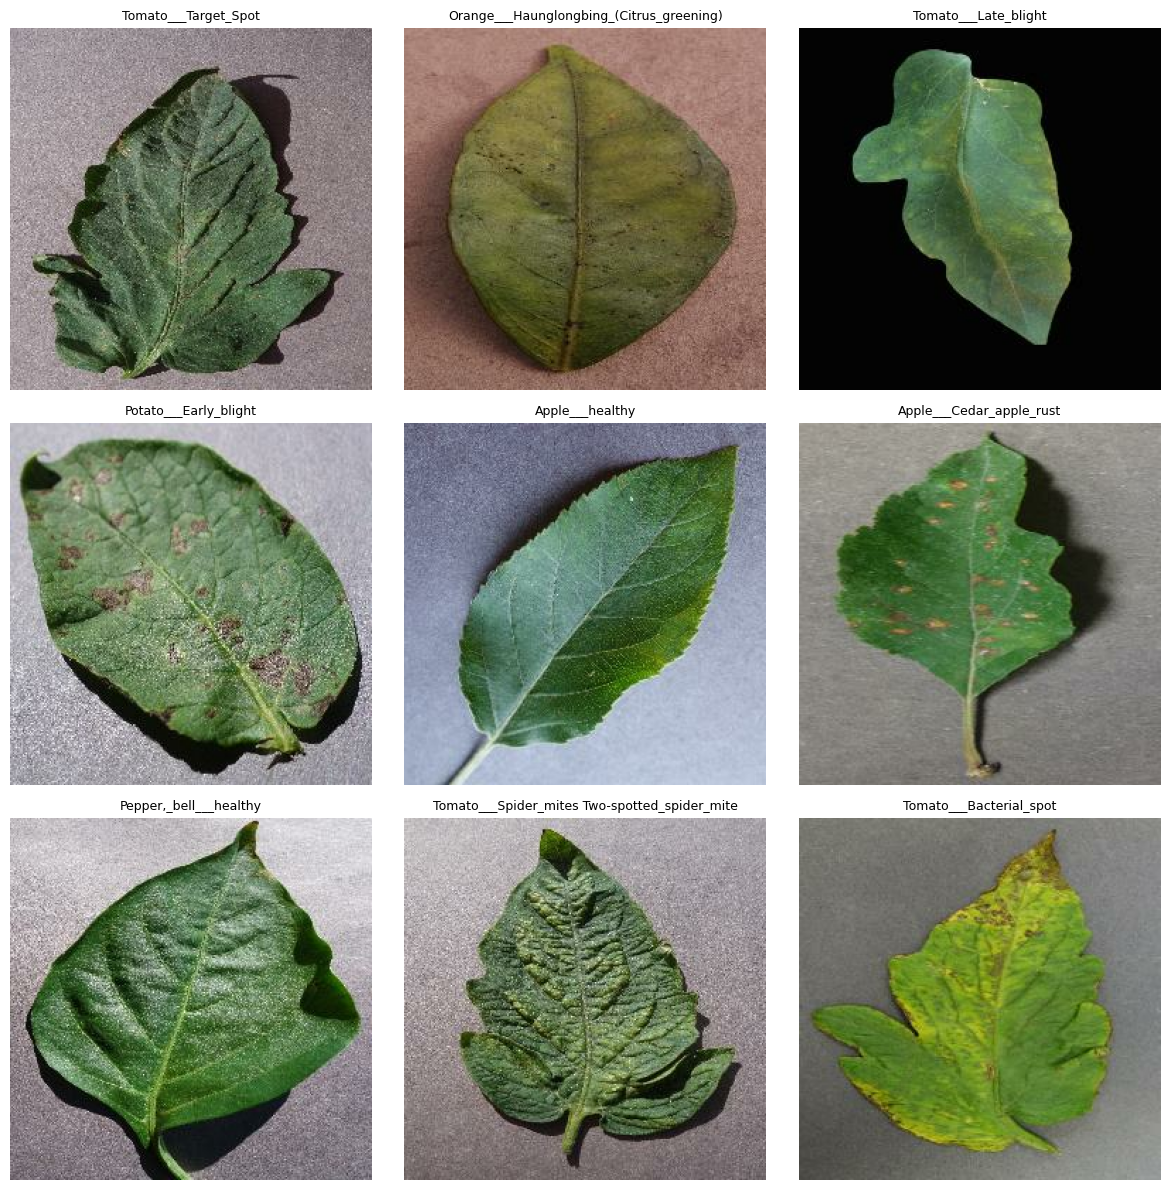

In [4]:
# Display 9 sample images with their labels
plt.figure(figsize=(12, 12))
for i, (image, label) in enumerate(ds_train.take(9)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image.numpy())
    plt.title(CLASS_NAMES[label.numpy()], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Προεπεξεργασια

Πριν δωσουμε τα δεδομενα στο μοντελο πρεπει:

- **Resize:** ολες οι εικονες σε 128x128 pixels (μικροτερο μεγεθος = πιο γρηγορη εκπαιδευση)
- **Normalize:** οι τιμες των pixels πανε απο [0, 255] σε [0, 1]
- **Data augmentation** (μονο στο training): random horizontal flip και brightness, για να βοηθησουμε το μοντελο να μην κανει overfit
- **Batch size:** 64 εικονες ανα batch
- **Prefetch:** το pipeline ετοιμαζει το επομενο batch οσο εκπαιδευεται το προηγουμενο

In [5]:
IMG_SIZE = 128
BATCH_SIZE = 64

# Resize images and normalize pixel values to [0, 1]
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Data augmentation - applied only to training set
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

# Build the training pipeline (with augmentation + shuffle)
ds_train_prepared = (ds_train
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

# Validation pipeline (no augmentation, no shuffle)
ds_val_prepared = (ds_val
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

# Test pipeline (no augmentation, no shuffle)
ds_test_prepared = (ds_test
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

print("Data pipelines ready")

Data pipelines ready


## 6. Κατασκευη του CNN (baseline)

Φτιαχνουμε ενα **custom CNN** απο την αρχη με 4 convolutional blocks. Καθε block εχει:

- **Conv2D:** ανιχνευει χαρακτηριστικα στην εικονα (ακμες, χρωματα, υφες, μοτιβα)
- **BatchNormalization:** σταθεροποιει την εκπαιδευση και τη κανει πιο γρηγορη
- **MaxPooling2D:** μειωνει τη διασταση της εικονας στο μισο

Αρχιτεκτονικη:

```
Input (128x128x3)
  |
[Conv2D 32  + BN + MaxPool] -> block 1: βασικα χαρακτηριστικα (ακμες, χρωματα)
  |
[Conv2D 64  + BN + MaxPool] -> block 2: πιο συνθετα μοτιβα (υφες)
  |
[Conv2D 128 + BN + MaxPool] -> block 3: μεγαλυτερες δομες (κηλιδες)
  |
[Conv2D 128 + BN + MaxPool] -> block 4: υψηλου επιπεδου χαρακτηριστικα
  |
GlobalAveragePooling2D      -> συμπυκνωνει σε ενα διανυσμα
  |
Dense(128) + Dropout(0.4)   -> classification layer + regularization
  |
Dense(38) softmax           -> πιθανοτητες για καθε κατηγορια
```

Αυτο ειναι το **baseline** μοντελο μας με χειροκινητα επιλεγμενες υπερπαραμετρους. Μετα θα κανουμε tuning για να δουμε αν μπορουμε να το βελτιωσουμε.

In [6]:
from tensorflow.keras import layers, models

# Build the custom CNN architecture
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1
    layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(128, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,654 (1.01 MB)

 Trainable params: 262,950 (1.00 MB)

 Non-trainable params: 704 (2.75 KB)

## 7. Εκπαιδευση baseline

Εκπαιδευουμε για **10 epochs**. Καθε epoch θα παρει περιπου 1 λεπτο στο Colab GPU (T4).
Συνολικα ~10-15 λεπτα.

Σε καθε epoch το μοντελο βλεπει ολο το training set και προσαρμοζει τα βαρη του.

In [7]:
EPOCHS = 10

history = model.fit(
    ds_train_prepared,
    validation_data=ds_val_prepared,
    epochs=EPOCHS
)

Epoch 1/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.6491 - loss: 1.2326 - val_accuracy: 0.4859 - val_loss: 2.0297
Epoch 2/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8531 - loss: 0.4713 - val_accuracy: 0.6834 - val_loss: 1.0290
Epoch 3/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9067 - loss: 0.2958 - val_accuracy: 0.7725 - val_loss: 0.6942
Epoch 4/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9330 - loss: 0.2095 - val_accuracy: 0.9337 - val_loss: 0.2018
Epoch 5/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9452 - loss: 0.1683 - val_accuracy: 0.9054 - val_loss: 0.3137
Epoch 6/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9547 - loss: 0.1419 - val_accuracy: 0.9433 - val_loss: 0.1819
Epoch 7/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9584 - loss: 0.1277 - val_accuracy: 0.8840 - val_loss: 0.4067
Epoch 8/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9650 - loss: 0.1071 - val_acc

## 8. Καμπυλες εκπαιδευσης

Σχεδιαζουμε πως εξελιχθηκαν το **accuracy** και το **loss** σε train και validation set.

**Πως να τα διαβασουμε:**
- Αν το train accuracy ειναι πολυ μεγαλυτερο απο το validation accuracy → **overfitting** (το μοντελο μαθαινει απο μνημης)
- Αν και τα δυο ανεβαινουν μαζι → καλη εκπαιδευση
- Αν το loss σταθεροποιειται → φτασαμε στο πλατο, ισως χρειαζεται lower learning rate

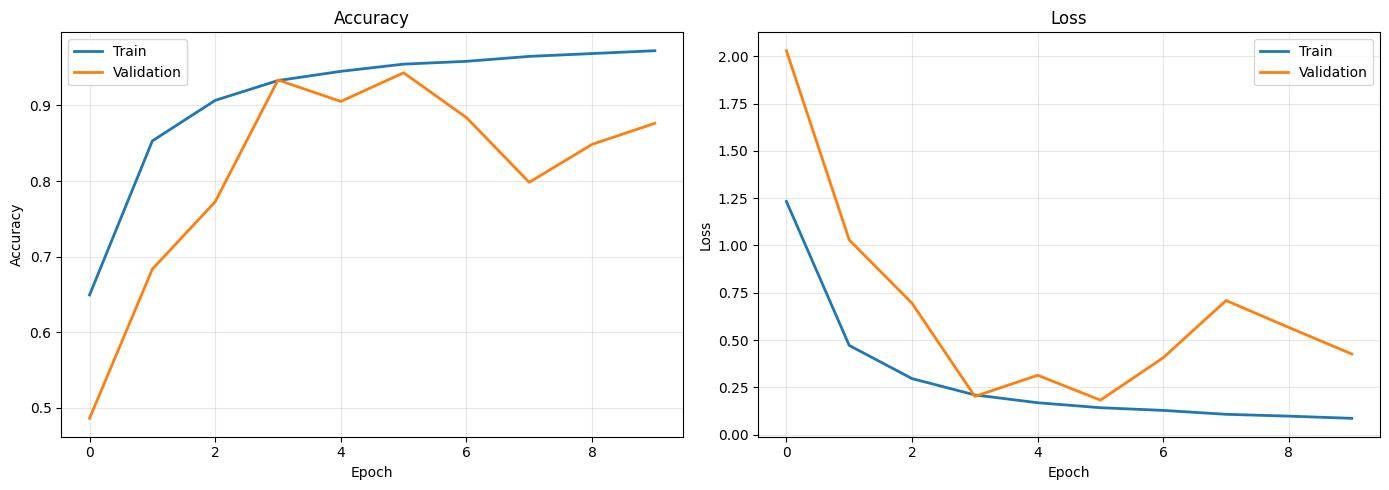

In [8]:
# Plot training and validation curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Αξιολογηση στο test set (baseline)

Υπολογιζουμε το τελικο **test accuracy** σε δεδομενα που το μοντελο **δεν εχει ξαναδει**.
Αυτος ειναι ο πιο αξιοπιστος δεικτης για το ποσο καλα γενικευει το μοντελο.

In [9]:
# Final evaluation on the held-out test set
test_loss, test_acc = model.evaluate(ds_test_prepared, verbose=0)
print(f"Baseline test accuracy: {test_acc * 100:.2f}%")
print(f"Baseline test loss:     {test_loss:.4f}")

Baseline test accuracy: 87.54%
Baseline test loss:     0.4420


## 10. Confusion Matrix

Δειχνει σε ποιες κατηγοριες κανει λαθη το μοντελο:
- **Διαγωνιος** = σωστες προβλεψεις (οσο πιο σκουρα, τοσο καλυτερα)
- **Εκτος διαγωνιου** = λαθη (true label vs predicted label)

Με 38 κλασεις φαινεται πυκνο, αλλα μπορουμε να εντοπισουμε ζευγη κατηγοριων που μπερδευονται μεταξυ τους.

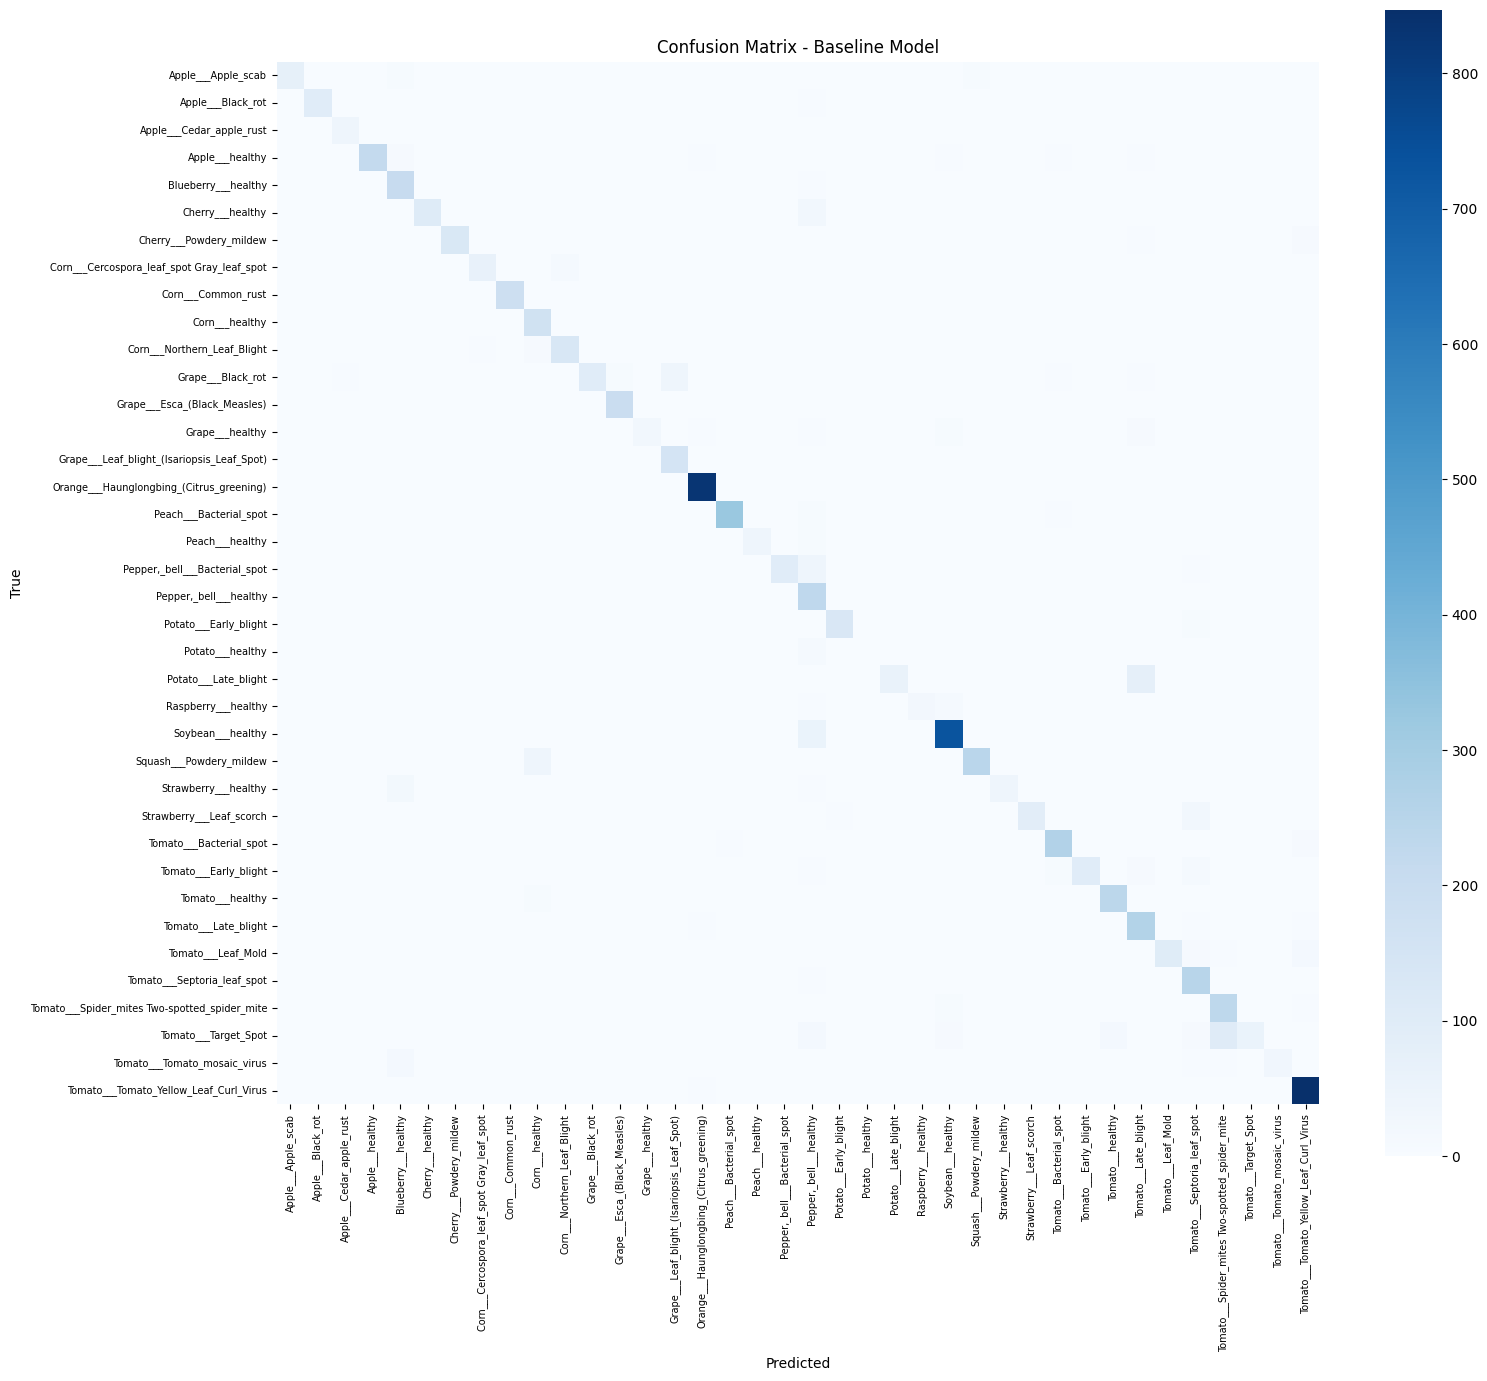

In [10]:
# Get predictions on the entire test set
y_true = []
y_pred = []

for images, labels in ds_test_prepared:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(cm, cmap='Blues', cbar=True, square=True,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Baseline Model')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

## 11. Παραδειγματα προβλεψεων

Δειχνουμε 9 τυχαιες εικονες απο το test set με την προβλεψη του μοντελου, την πραγματικη κατηγορια και το confidence (ποσο σιγουρο ηταν).

- **Πρασινος τιτλος:** σωστη προβλεψη
- **Κοκκινος τιτλος:** λαθος προβλεψη

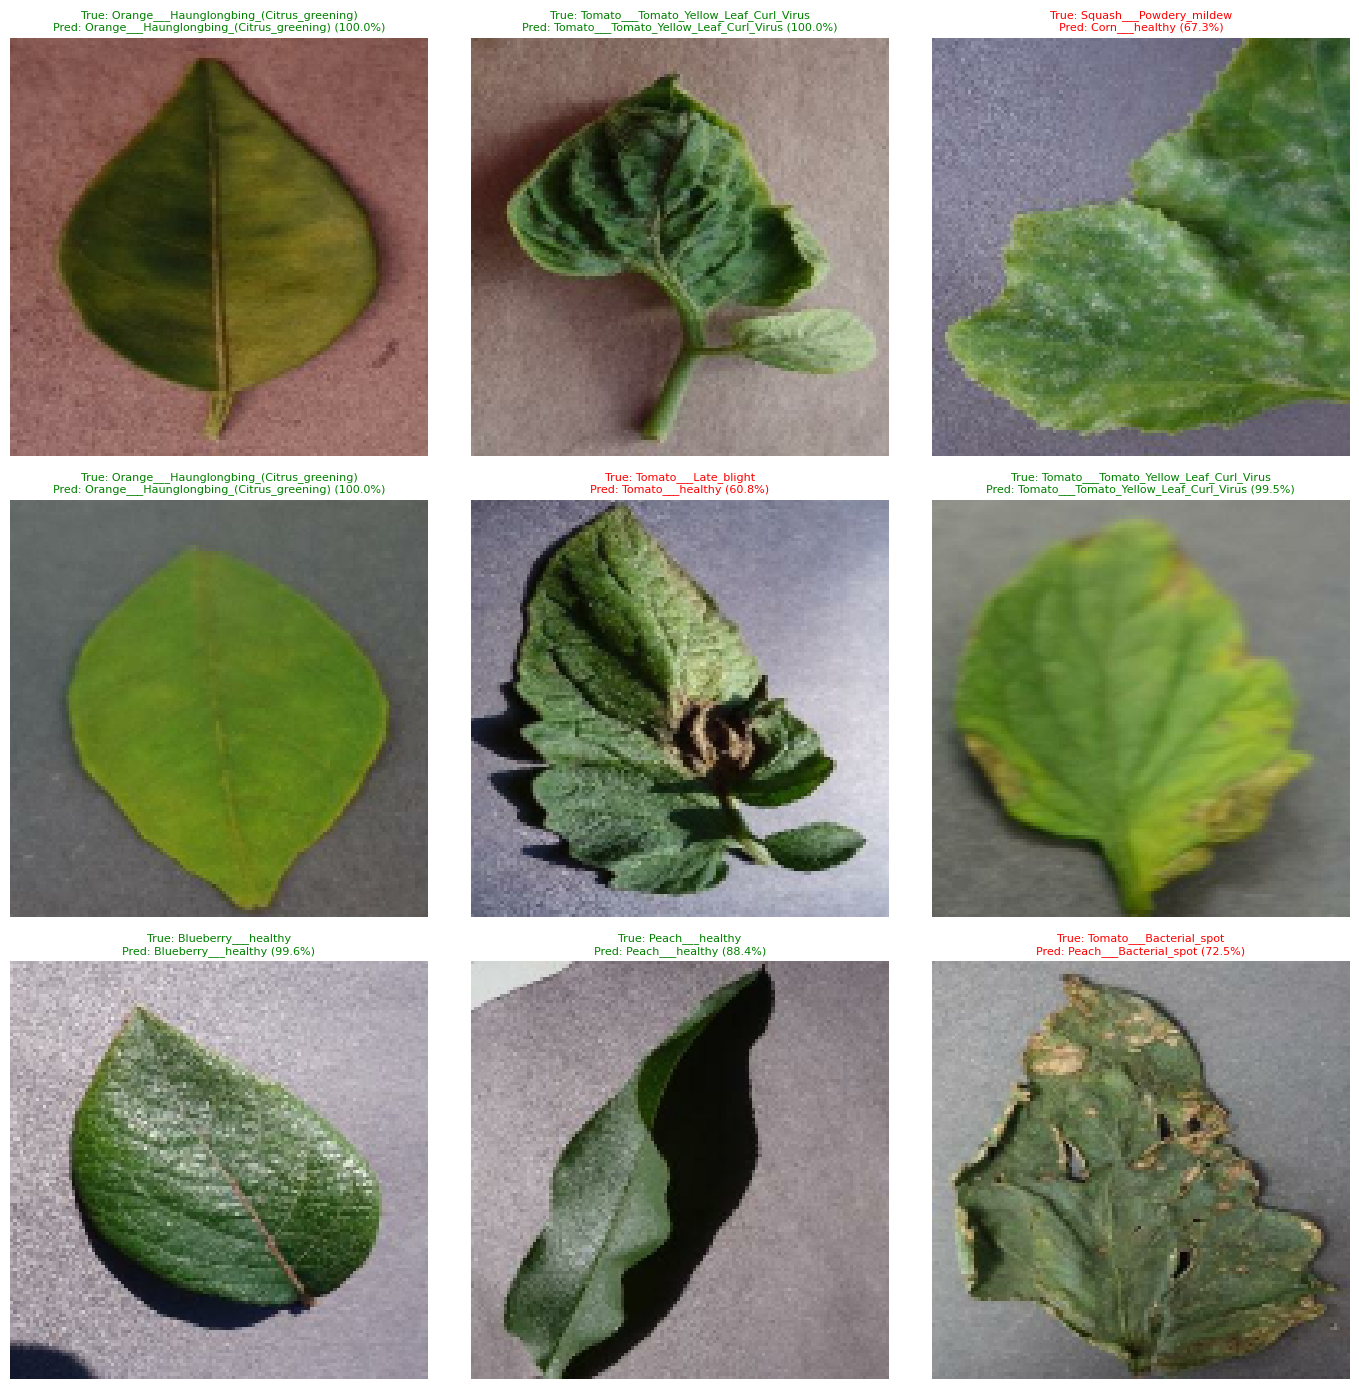

In [11]:
# Take one batch of test images and predict
for images, labels in ds_test_prepared.take(1):
    test_images = images.numpy()
    test_labels = labels.numpy()
    break

predictions = model.predict(test_images, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

# Show 9 random samples with predictions
indices = np.random.choice(len(test_images), 9, replace=False)

plt.figure(figsize=(14, 14))
for i, idx in enumerate(indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_images[idx])

    true_label = CLASS_NAMES[test_labels[idx]]
    pred_label = CLASS_NAMES[predicted_labels[idx]]
    confidence = predictions[idx][predicted_labels[idx]] * 100

    is_correct = test_labels[idx] == predicted_labels[idx]
    color = 'green' if is_correct else 'red'

    title = f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)"
    plt.title(title, fontsize=8, color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 12. Hyperparameter Tuning με Keras Tuner

Μεχρι τωρα διαλεξαμε **χειροκινητα** τις υπερπαραμετρους (dropout=0.4, dense_units=128, learning_rate=1e-3). Αλλα πως ξερουμε οτι ειναι οι καλυτερες;

Θα χρησιμοποιησουμε το **Keras Tuner** για να δοκιμασουμε αυτοματα διαφορετικους συνδυασμους και να βρουμε τον καλυτερο συμφωνα με το **validation accuracy**.

**Τι θα κανουμε tune:**

| Hyperparameter | Τιμες προς δοκιμη |
|---|---|
| `dropout_rate` | 0.2, 0.3, 0.4, 0.5 |
| `dense_units` | 64, 128, 256 |
| `learning_rate` | 1e-3, 5e-4, 1e-4 |

**Στρατηγικη:** RandomSearch με 5 trials, 5 epochs ανα trial.

> **Προσοχη:** Αυτο το βημα ειναι αργο! Θα παρει ~25 λεπτα. Αν θες, μπορεις να το παραλειψεις αν εισαι ικανοποιημενος με το baseline.

Ξεκιναμε εγκαθιστωντας το keras-tuner.

In [12]:
# Install keras-tuner (usually available on Colab, but ensure it's there)
!pip install -q keras-tuner

import keras_tuner as kt

print(f"Keras Tuner version: {kt.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 9.9 MB/s eta 0:00:00
Keras Tuner version: 1.4.8


### 12.1 Συναρτηση κατασκευης μοντελου με υπερπαραμετρους

Φτιαχνουμε μια συναρτηση `build_model(hp)` που δεχεται ενα αντικειμενο `hp` (HyperParameters) και χτιζει ενα μοντελο με τις τιμες που θα δοκιμαστουν. Ο tuner καλει αυτη τη συναρτηση πολλες φορες με διαφορετικες τιμες.

In [13]:
# Function that builds a CNN model given a set of hyperparameters
def build_model(hp):
    # Define the search space for each hyperparameter
    dropout_rate = hp.Choice('dropout', values=[0.2, 0.3, 0.4, 0.5])
    dense_units = hp.Choice('dense_units', values=[64, 128, 256])
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    # Same architecture as baseline, but dropout/dense/lr are now tunable
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("build_model function ready")

build_model function ready


### 12.2 Εκτελεση της αναζητησης

Ο `RandomSearch` διαλεγει τυχαιους συνδυασμους υπερπαραμετρων και εκπαιδευει το μοντελο για 5 epochs ανα συνδυασμο. Κραταει αυτον με το **καλυτερο val_accuracy**.

Αναμενομενος χρονος: ~25 λεπτα στο Colab GPU (5 trials × 5 epochs).

In [14]:
# Set up the Random Search tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,                # Number of HP combinations to try
    executions_per_trial=1,
    directory='kt_results',
    project_name='plant_disease',
    overwrite=True
)

# Show the search space
tuner.search_space_summary()

# Run the search (this is the slow step)
tuner.search(
    ds_train_prepared,
    validation_data=ds_val_prepared,
    epochs=5,
    verbose=1
)

print("\nSearch complete!")

Trial 5 Complete [00h 00m 57s]
val_accuracy: 0.9253621697425842

Best val_accuracy So Far: 0.9269580245018005
Total elapsed time: 00h 05m 16s

Search complete!


### 12.3 Καλυτερες υπερπαραμετροι

Παιρνουμε τον συνδυασμο που εδωσε το υψηλοτερο validation accuracy και βλεπουμε ολους τους συνδυασμους που δοκιμαστηκαν.

In [15]:
# Get the best hyperparameters from the search
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("=" * 50)
print("BEST HYPERPARAMETERS FOUND")
print("=" * 50)
print(f"  dropout_rate:  {best_hps.get('dropout')}")
print(f"  dense_units:   {best_hps.get('dense_units')}")
print(f"  learning_rate: {best_hps.get('learning_rate')}")
print("=" * 50)

# Show summary of all trials
print("\nAll trials summary:\n")
tuner.results_summary(num_trials=5)

BEST HYPERPARAMETERS FOUND
  dropout_rate:  0.2
  dense_units:   256
  learning_rate: 0.0005

All trials summary:

Results summary
Results in kt_results/plant_disease
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 2 summary
Hyperparameters:
dropout: 0.2
dense_units: 256
learning_rate: 0.0005
Score: 0.9269580245018005

Trial 4 summary
Hyperparameters:
dropout: 0.4
dense_units: 64
learning_rate: 0.0005
Score: 0.9253621697425842

Trial 3 summary
Hyperparameters:
dropout: 0.3
dense_units: 256
learning_rate: 0.0001
Score: 0.9001964330673218

Trial 0 summary
Hyperparameters:
dropout: 0.5
dense_units: 128
learning_rate: 0.0001
Score: 0.8817824721336365

Trial 1 summary
Hyperparameters:
dropout: 0.4
dense_units: 64
learning_rate: 0.0001
Score: 0.846550464630127


## 13. Εκπαιδευση του τελικου μοντελου

Με τις καλυτερες υπερπαραμετρους που βρηκαμε, εκπαιδευουμε το **τελικο μοντελο για 15 epochs** (περισσοτερα απο το baseline για να δουμε αν μπορει να φτασει σε υψηλοτερο accuracy).

In [16]:
# Build the model with the best hyperparameters
best_model = tuner.hypermodel.build(best_hps)

best_model.summary()

# Train for more epochs now that we have the best HPs
history_best = best_model.fit(
    ds_train_prepared,
    validation_data=ds_val_prepared,
    epochs=15
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 285,030 (1.09 MB)

 Trainable params: 284,326 (1.08 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.7123 - loss: 1.0288 - val_accuracy: 0.4754 - val_loss: 1.8418
Epoch 2/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8971 - loss: 0.3344 - val_accuracy: 0.8678 - val_loss: 0.4137
Epoch 3/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9364 - loss: 0.2070 - val_accuracy: 0.9103 - val_loss: 0.2784
Epoch 4/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9583 - loss: 0.1372 - val_accuracy: 0.8713 - val_loss: 0.3943
Epoch 5/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9645 - loss: 0.1129 - val_accuracy: 0.9178 - val_loss: 0.2633
Epoch 6/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9718 - loss: 0.0891 - val_accuracy: 0.9114 - val_loss: 0.2750
Epoch 7/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9741 - loss: 0.0803 - val_accuracy: 0.9084 - val_loss: 0.2715
Epoch 8/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9761 - loss: 0.0725 - val_acc

## 14. Συγκριση Baseline vs Tuned μοντελο

Συγκρινουμε τα δυο μοντελα στο test set και δειχνουμε τις καμπυλες validation accuracy/loss για να δουμε αν το tuning εκανε τη διαφορα.

  Baseline test accuracy: 87.54%
  Tuned    test accuracy: 95.22%
  Improvement:            +7.69%


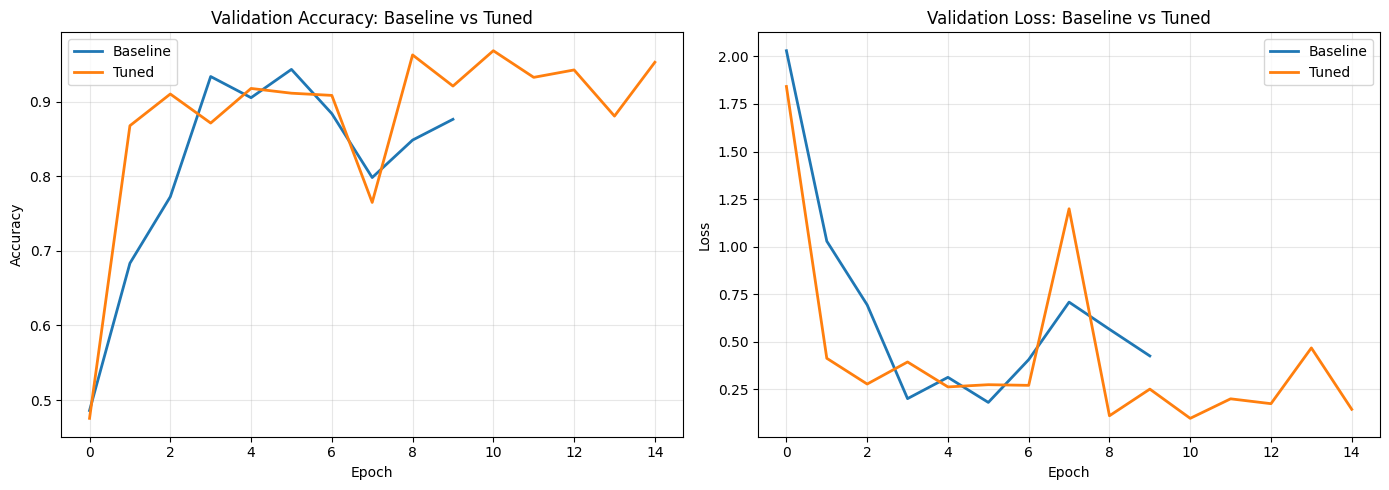

In [17]:
# Evaluate the tuned model on the test set
test_loss_best, test_acc_best = best_model.evaluate(ds_test_prepared, verbose=0)

# Print comparison
print("=" * 55)
print(f"  Baseline test accuracy: {test_acc * 100:.2f}%")
print(f"  Tuned    test accuracy: {test_acc_best * 100:.2f}%")
print(f"  Improvement:            {(test_acc_best - test_acc) * 100:+.2f}%")
print("=" * 55)

# Plot comparison curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['val_accuracy'], label='Baseline', linewidth=2)
axes[0].plot(history_best.history['val_accuracy'], label='Tuned', linewidth=2)
axes[0].set_title('Validation Accuracy: Baseline vs Tuned')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['val_loss'], label='Baseline', linewidth=2)
axes[1].plot(history_best.history['val_loss'], label='Tuned', linewidth=2)
axes[1].set_title('Validation Loss: Baseline vs Tuned')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Συμπερασματα

Φτιαξαμε ενα custom CNN απο την αρχη που ταξινομει 38 κατηγοριες υγειας/ασθενειας φυτων στο PlantVillage dataset, και βελτιστοποιησαμε τις υπερπαραμετρους του με Keras Tuner.

**Τι κανατε εσεις (για την παρουσιαση):**
- Σχεδιασατε την αρχιτεκτονικη του CNN (4 conv blocks)
- Στησατε το data pipeline με augmentation
- Εκπαιδευσατε ενα baseline μοντελο
- **Κανατε hyperparameter tuning με RandomSearch** για dropout, dense units, learning rate
- Συγκρινατε baseline vs tuned μοντελο σε test set
- Αναλυσατε τα αποτελεσματα με confusion matrix και sample predictions

**Επομενα βηματα (αν θελετε να βελτιωσετε):**
- Δοκιμη με transfer learning (ResNet50, MobileNetV2) για συγκριση
- Πιο επιθετικο data augmentation (rotation, zoom, contrast)
- Grad-CAM visualization για να δειτε σε ποια σημεια του φυλλου εστιαζει το δικτυο
- Tune και την αρχιτεκτονικη (αριθμο filters, αριθμο conv blocks)
- Hyperband αντι για RandomSearch (πιο αποδοτικο tuning)